# visualization

this notebook creates charts from the gold layer to understand electricity
consumption trends, anomaly detection and forecasting.

In [0]:
# importing libraries for visualization

import matplotlib.pyplot as plt

In [0]:
# switching to the project catalog

spark.sql("""
use catalog smart_meter_project_catalog
""")

DataFrame[]

In [0]:
# reading the gold tables

daily_df = spark.table("gold.daily_consumption")

monthly_df = spark.table("gold.monthly_consumption")

city_df = spark.table("gold.city_consumption")

house_df = spark.table("gold.house_type_consumption")

anomaly_df = spark.table("gold.anomaly_summary")

forecast_df = spark.table("gold.forecast_data")

In [0]:
# converting spark dataframes into pandas for plotting

daily_pd = daily_df.toPandas()

monthly_pd = monthly_df.toPandas()

city_pd = city_df.toPandas()

house_pd = house_df.toPandas()

anomaly_pd = anomaly_df.toPandas()

forecast_pd = forecast_df.toPandas()

# Daily consumption Trend --

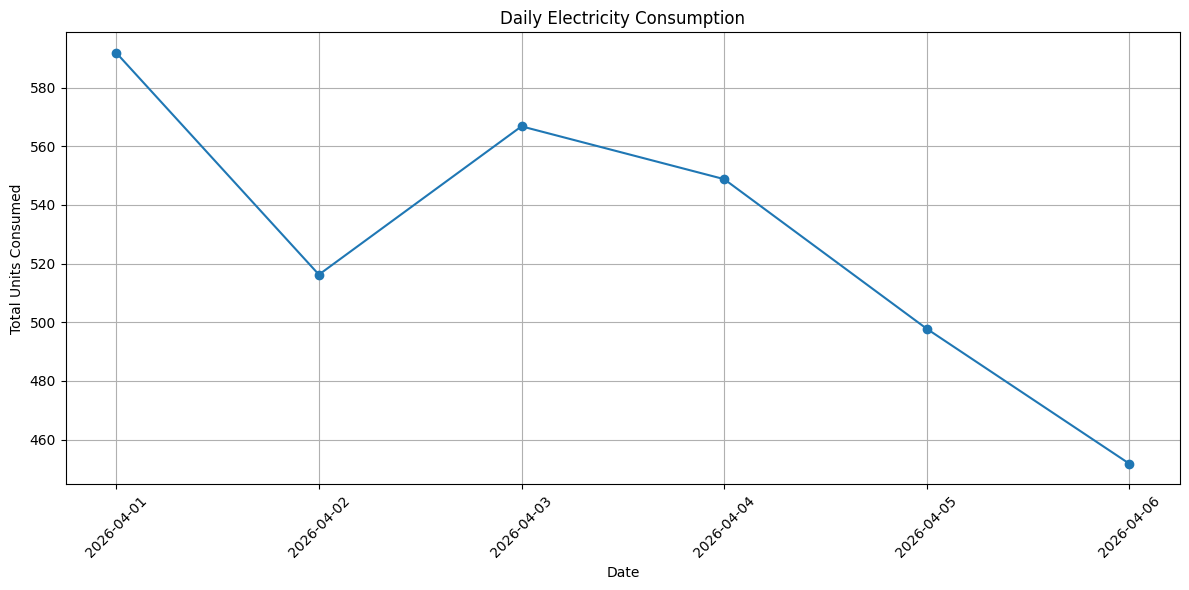

In [0]:
# plotting the daily electricity consumption trend

plt.figure(figsize=(12, 6))

plt.plot(
    daily_pd["reading_date"],
    daily_pd["total_units_consumed"],
    marker="o"
)

plt.title("Daily Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Total Units Consumed")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

# Monthly Consumption

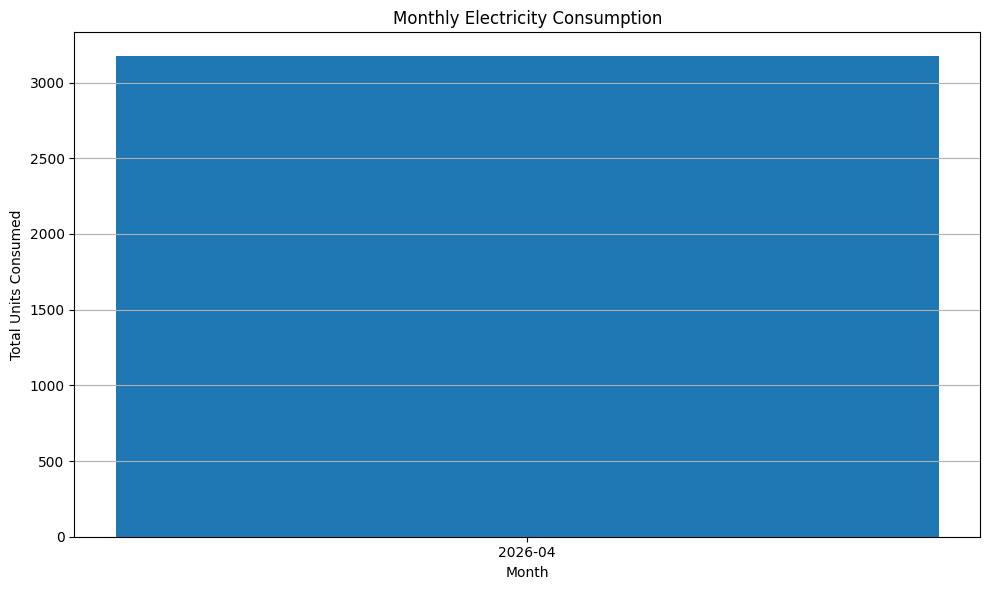

In [0]:
# plotting monthly electricity consumption

plt.figure(figsize=(10, 6))

plt.bar(
    monthly_pd["reading_month"],
    monthly_pd["total_units_consumed"]
)

plt.title("Monthly Electricity Consumption")
plt.xlabel("Month")
plt.ylabel("Total Units Consumed")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

# City-wise Consumption

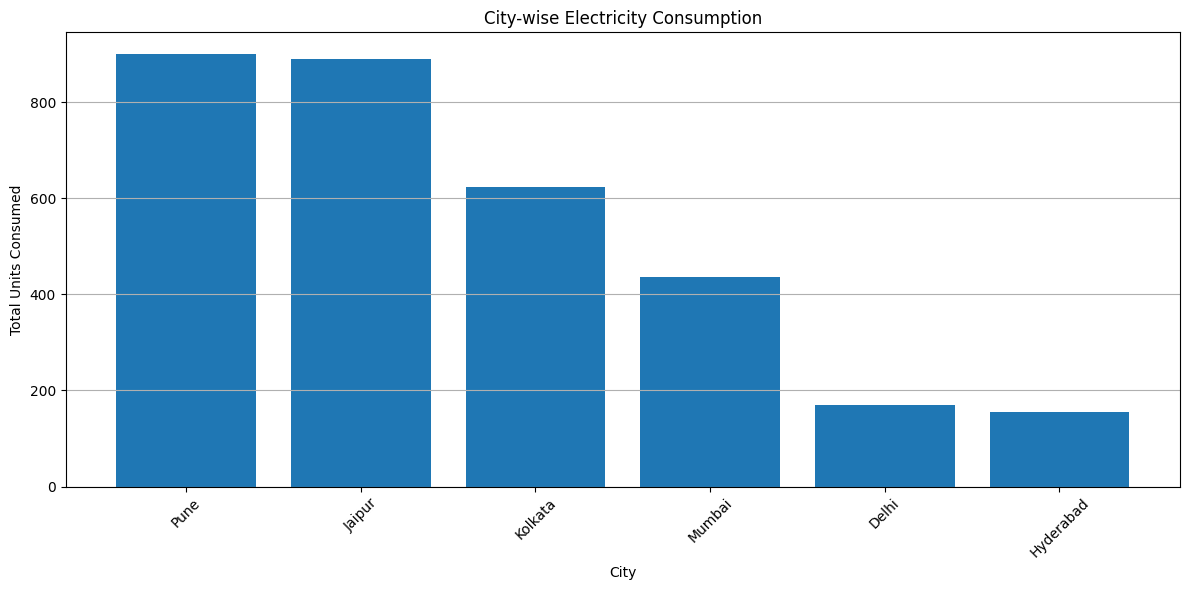

In [0]:
# comparing electricity consumption across cities

plt.figure(figsize=(12, 6))

plt.bar(
    city_pd["city"],
    city_pd["total_units_consumed"]
)

plt.title("City-wise Electricity Consumption")
plt.xlabel("City")
plt.ylabel("Total Units Consumed")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

# House Type Distribution

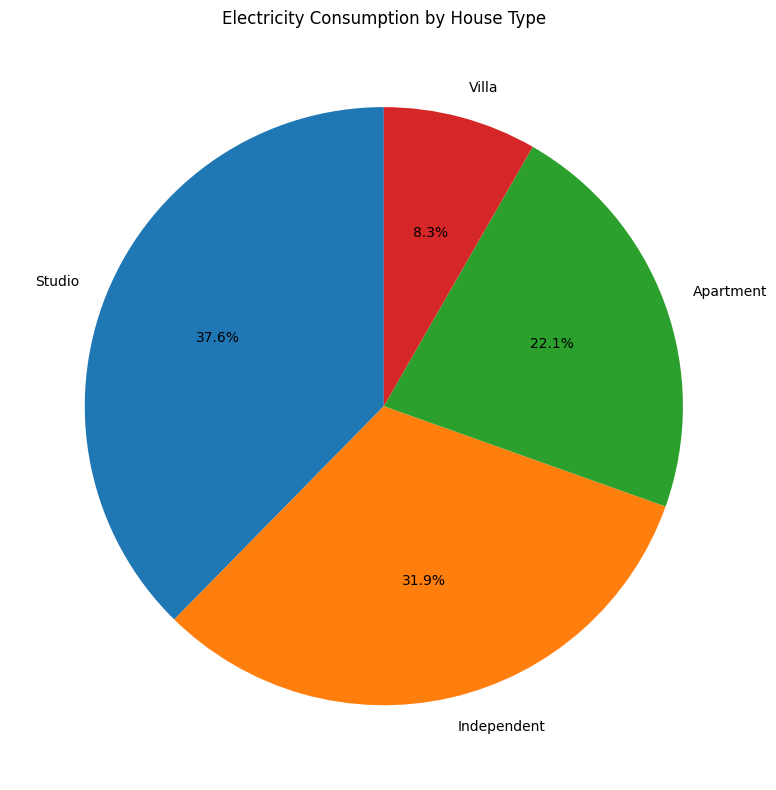

In [0]:
# showing electricity consumption based on house type

plt.figure(figsize=(8, 8))

plt.pie(
    house_pd["total_units_consumed"],
    labels=house_pd["house_type"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Electricity Consumption by House Type")

plt.tight_layout()

plt.show()

# Anomaly Summary

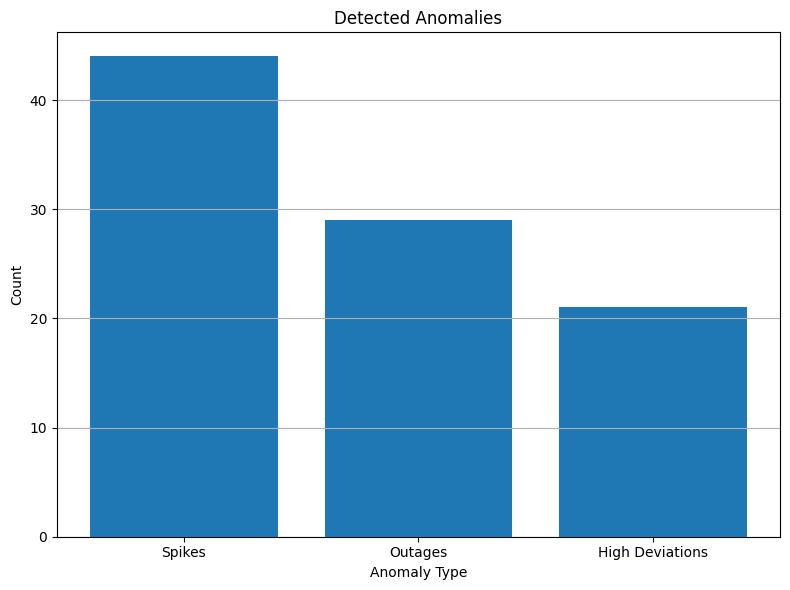

In [0]:
# plotting the detected anomalies

anomaly_counts = [
    anomaly_pd["total_spikes"][0],
    anomaly_pd["total_possible_outages"][0],
    anomaly_pd["total_high_deviations"][0]
]

anomaly_labels = [
    "Spikes",
    "Outages",
    "High Deviations"
]

plt.figure(figsize=(8, 6))

plt.bar(
    anomaly_labels,
    anomaly_counts
)

plt.title("Detected Anomalies")
plt.xlabel("Anomaly Type")
plt.ylabel("Count")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

#7-Day SMA Forecast Trend

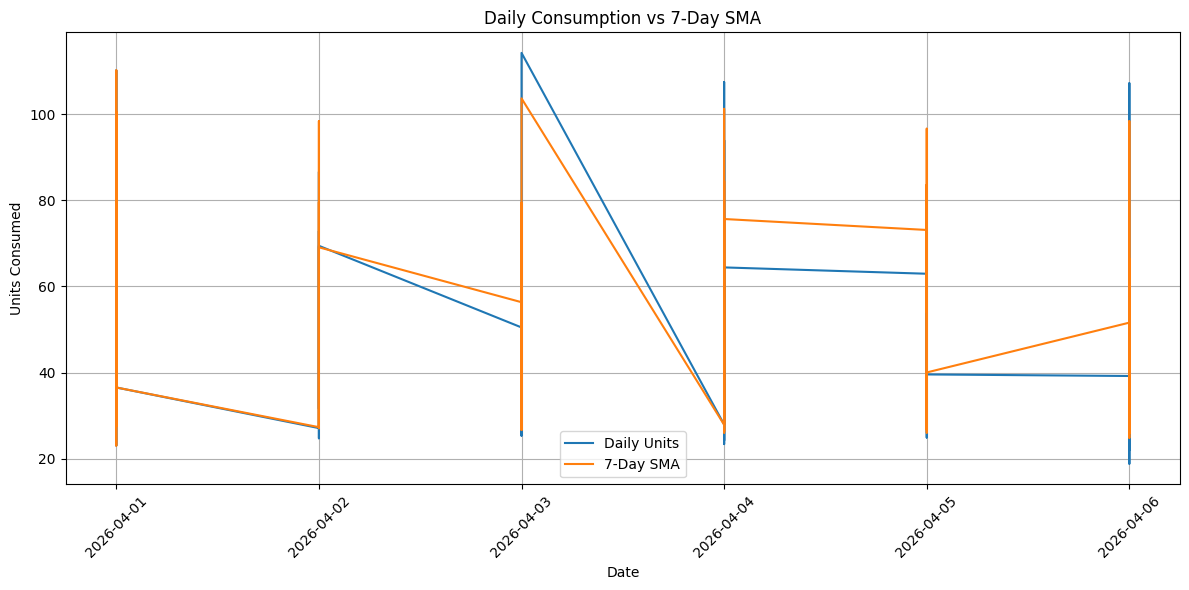

In [0]:
# plotting the daily units and seven day moving average

plt.figure(figsize=(12, 6))

meter_data = (
    forecast_pd
    .sort_values("reading_date")
    .head(100)
)

plt.plot(
    meter_data["reading_date"],
    meter_data["daily_units"],
    label="Daily Units"
)

plt.plot(
    meter_data["reading_date"],
    meter_data["seven_day_average"],
    label="7-Day SMA"
)

plt.title("Daily Consumption vs 7-Day SMA")
plt.xlabel("Date")
plt.ylabel("Units Consumed")

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()